In [1]:
%reload_ext autoreload
%autoreload 2

import numpy as np
import os, sys
from astropy.io import fits
import healpy as hp
#import pandas as pd

from scipy import optimize
from scipy.stats import poisson

sys.path.append('..')

import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc_file('../notebooks/matplotlibrc')

In [2]:
import utils.create_mask as cm
from utils.cart import to_cart

In [3]:
from common import TemplateWithEnergy, Exposure

In [4]:
%%html
<style>
.dataframe th {font-size: 18px;}
.dataframe td {font-size: 16px;}
</style>

## 1. Build masks

In [4]:
# masks
nside = 512
n_pixels = 80
pixelsize = 0.5
mask_ps = np.load("data/fermidata/pscmask_Jun19_NSIDE512.npy") == 1

mask_roi = to_cart(cm.make_mask_total(nside=nside, band_mask=True, band_mask_range=2., mask_ring=True, inner=0, outer=20., custom_mask=mask_ps), n_pixels=n_pixels, pixelsize=pixelsize) > 0
mask_square = to_cart(cm.make_mask_total(nside=nside, band_mask=True, band_mask_range=2., mask_ring=False, inner=0, outer=20., custom_mask=mask_ps), n_pixels=n_pixels, pixelsize=pixelsize) > 0
mask_plane = to_cart(cm.make_mask_total(nside=nside, band_mask=True, band_mask_range=2., mask_ring=True, inner=0, outer=20.,), n_pixels=n_pixels, pixelsize=pixelsize) > 0

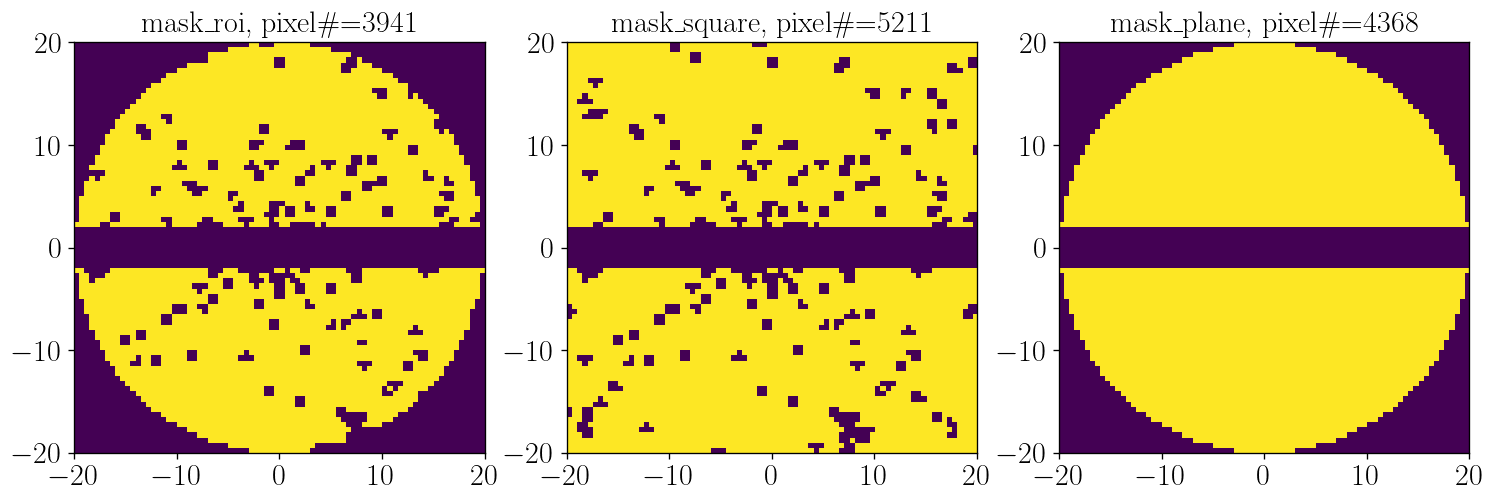

In [5]:
fig, axs = plt.subplots(1, 3, figsize=(15,5))
for i, (name, m) in enumerate(zip(['mask_roi', 'mask_square', 'mask_plane'], [mask_roi, mask_square, mask_plane])):
    axs[i].imshow(~m, extent=(-20,20,-20,20))
    axs[i].set(title=f'{name}, pixel\#={np.sum(~m)}')
    #axs[i].set(xlabel='l [deg]', ylabel='b [deg]')

## 2. Poisson fit preparation

In [6]:
def likelihood(theta, data, temps, mask=None):
    """ Pixel-wise product Poisson log-likelihood
    """ 
    if mask is None:
        mask = np.zeros_like(temps[0], dtype=bool)
    temp_sum = np.einsum("ij,i -> j", temps[:, ~mask], theta)
    return - poisson.logpmf(data[~mask], temp_sum).mean()

In [7]:
def show(entrys, columns=None):
    print('\t'.join(columns))
    for entry in entrys:
        print(entry[0]+'\t'+'\t'.join([('%.4f' % entry[i]) for i in range(1, len(entry))]))

## 3. Fitting

In [13]:
# config
exposure_name = '718weeks'
mask = mask_roi

In [15]:
temp = {}

ccw_temps = ['ccwaics', 'ccwapibrem', 'ccwfics', 'ccwfpibrem']

# common templates
for name in ['bub', 'dsk', 'gce', 'iso', 'psc', 'p6v11'] + ccw_temps:
    temp[name+'_cart'] = np.load(f'data/templates_Jun19/{name}_cart.npy')

# config templates
if exposure_name == '573weeks':
    for name in [s+'_gtsrcmap' for s in ['p6v11']+ccw_temps]:
        temp[name] = np.load(f'data/templates_{exposure_name}/{name}.npy')
    for name in [s+'_kingpsf' for s in ['p6v11']+ccw_temps]:
        temp[name] = np.load(f'data/templates_{exposure_name}/{name}.npy')
    diff_models = {
        'p6v11_c' : ['p6v11_cart'],
        'p6v11_gt': ['p6v11_gtsrcmap'],
        'p6v11_kp': ['p6v11_kingpsf'],
        'ccwa_c'  : ['ccwaics_cart', 'ccwapibrem_cart'],
        'ccwf_c'  : ['ccwfics_cart', 'ccwfpibrem_cart'],
        'ccwa_kp' : ['ccwaics_kingpsf', 'ccwapibrem_kingpsf'],
        'ccwf_kp' : ['ccwfics_kingpsf', 'ccwfpibrem_kingpsf'],
        'ccwa_gt' : ['ccwaics_gtsrcmap', 'ccwapibrem_gtsrcmap'],
        'ccwf_gt' : ['ccwfics_gtsrcmap', 'ccwfpibrem_gtsrcmap']
    }
        
elif exposure_name == '718weeks':
    for name in [s+'_kingpsf' for s in ['p6v11']+ccw_temps]:
        temp[name] = np.load(f'data/templates_{exposure_name}/{name}.npy')
    diff_models = {
        'p6v11_c' : ['p6v11_cart'],
        'p6v11_kp': ['p6v11_kingpsf'],
        'ccwa_c'  : ['ccwaics_cart', 'ccwapibrem_cart'],
        'ccwf_c'  : ['ccwfics_cart', 'ccwfpibrem_cart'],
        'ccwa_kp' : ['ccwaics_kingpsf', 'ccwapibrem_kingpsf'],
        'ccwf_kp' : ['ccwfics_kingpsf', 'ccwfpibrem_kingpsf']
    }

# normalize with mask
for name in temp:
    temp[name] /= np.mean(temp[name][~mask])
print(list(temp.keys()))

['bub_cart', 'dsk_cart', 'gce_cart', 'iso_cart', 'psc_cart', 'p6v11_cart', 'ccwaics_cart', 'ccwapibrem_cart', 'ccwfics_cart', 'ccwfpibrem_cart', 'p6v11_kingpsf', 'ccwaics_kingpsf', 'ccwapibrem_kingpsf', 'ccwfics_kingpsf', 'ccwfpibrem_kingpsf']


In [16]:
counts = np.load(f'data/fermidata/counts_{exposure_name}.npy')
other_temps = ['gce_cart', 'psc_cart', 'iso_cart', 'bub_cart']

columns = ['model', 'LL'] + other_temps + ['diff1', 'diff2']
entrys = []

use_sho = False

for m, diff_temps in diff_models.items():
    temp_names = other_temps + diff_temps
    temps = np.array([temp[name] for name in temp_names])
    bounds = tuple([(0, 5) for _ in temp_names[:-2]] + [(0, 35), (0, 35)])
    if use_sho:
        result = optimize.shgo(likelihood, bounds=bounds, args=(counts, temps, mask))
    else:
        x0 = 2*np.ones((len(temp_names),))
        result = optimize.minimize(likelihood, x0=x0, bounds=bounds, args=(counts, temps, mask))
    entry = [m] + [-result.fun * np.sum(~mask)] + list(result.x)
    #entry += [''] * (len(columns) - len(entry))
    entrys.append(entry)
    
#fit = pd.DataFrame(entrys, columns=columns)
print(f'use_sh0={use_sho}, exposure_name={exposure_name}')
show(entrys, columns=columns)

use_sh0=False, exposure_name=718weeks
model	LL	gce_cart	psc_cart	iso_cart	bub_cart	diff1	diff2
p6v11_c	-13029.9908	2.8895	0.1494	0.0000	1.2242	27.7326
p6v11_kp	-12999.8950	3.2009	0.1507	0.0000	1.1395	27.5045
ccwa_c	-13009.6571	4.0436	0.1465	0.0000	0.8240	11.8686	15.1134
ccwf_c	-13006.8814	3.6646	0.1421	0.0000	0.6828	10.7503	16.7561
ccwa_kp	-13012.3824	4.1515	0.1462	0.0000	0.7954	11.7470	15.1556
ccwf_kp	-13050.7060	3.7693	0.1421	0.0000	0.5616	10.9913	16.5315


## A. Fit results

c: processed by gtsrcmap with 573 week data, converted to healpix then to cartesian
gt: processed by gtsrcmap with 573 week data
kp: multiplied by exposure of 573 or 718 week data depending on fit, applied King psf

### 573 week

In [ ]:
# mask_roi
model	LL	        gce	    psc	    iso	    bub	    diff1	diff2
p6v11_c	-12526.4749	2.5347	0.1211	0.0000	0.9758	23.6433
p6v11_gt-12518.3773	2.5857	0.1209	0.0000	1.1750	23.3932
p6v11_kp-12494.5528	2.7122	0.1236	0.0000	0.9164	23.5226
ccwa_c	-12507.3194	3.5651	0.1186	0.0000	0.6334	9.9588	12.9989
ccwf_c	-12491.6006	3.2458	0.1147	0.0000	0.5228	8.9848	14.4067
ccwa_kp	-12508.4697	3.5423	0.1198	0.0000	0.6223	10.0110	12.9795
ccwf_kp	-12530.9318	3.2152	0.1164	0.0000	0.4261	9.3556	14.1616
ccwa_gt	-12498.3873	3.4821	0.1187	0.0000	0.8365	9.6831	13.1544
ccwf_gt	-12484.5792	3.1518	0.1150	0.0000	0.7129	8.7347	14.5604

In [ ]:
        p6v11		ccwa		ccwf	    expectation
gtsm_c	-12526.4749	-12507.3194	-12491.6006 good, gtsrcmap but interpolated to healpix then back
gtsm	-12518.3773	-12498.3873	-12484.5792 best, gtsrcmap
kingpsf	-12494.5528	-12508.4697	-12530.9318 worst, simple kingpsf convolution

what's going on with p6v11_kingpsf ???

### 718 week

In [ ]:
# mask_roi
model	LL	        gce	    psc	    iso	    bub	    diff1	diff2
p6v11_c	-13029.9908	2.8895	0.1494	0.0000	1.2242	27.7326
p6v11_kp-12999.8950	3.2009	0.1507	0.0000	1.1395	27.5045
ccwa_c	-13009.6571	4.0436	0.1465	0.0000	0.8240	11.8686	15.1134
ccwf_c	-13006.8814	3.6646	0.1421	0.0000	0.6828	10.7503	16.7561
ccwa_kp	-13012.3824	4.1515	0.1462	0.0000	0.7954	11.7470	15.1556
ccwf_kp	-13050.7060	3.7693	0.1421	0.0000	0.5616	10.9913	16.5315

In [ ]:
        p6v11		ccwa		ccwf	    expectation
gtsm_c	-13029.9908	-13009.6571	-13006.8814 good, gtsrcmap but interpolated to healpix then back
kingpsf	-12999.8950	-13012.3824	-13050.7060 worst, simple kingpsf convolution

## B. Fit results (old)

### 718 week

In [ ]:
# minimize, mask=roi, ccwfpibrem psf_r *= 3
model	LL	    gce	    psc	    iso	    bub     diff1	diff2
p6v11	-3.3063	2.8895	0.1494	0.0000	1.2241	27.7328
ccwa	-3.3018	4.1515	0.1462	0.0000	0.7955	11.7471	15.1554
ccwf	-3.3012	3.7979	0.1408	0.0000	0.7108	10.2118	17.1344

In [ ]:
# minimize, mask=roi, (no psc)
model	LL	    gce	    iso	    bub     diff1	diff2
p6v11	-3.3410	2.7172	0.0000	1.2032	28.0752
ccwa	-3.3349	3.9945	0.0000	0.7725	11.8935	15.3352
ccwf	-3.3426	3.6439	0.0000	0.5413	11.0140	16.7965

In [ ]:
# sho, mask=roi
model	LL	    gce	    psc	    iso	    bub     diff1	diff2
p6v11	-3.3063	2.8894	0.1494	0.0000	1.2242	27.7326
ccwa	-3.3018	4.1515	0.1462	0.0000	0.7955	11.7470	15.1554
ccwf	-3.3115	3.7695	0.1421	0.0000	0.5616	10.9911	16.5314

In [ ]:
# minimize, mask=roi
model	LL	    gce	    psc	    iso	    bub     diff1	diff2
p6v11	-3.3063	2.8895	0.1494	0.0000	1.2241	27.7328
ccwa	-3.3018	4.1515	0.1462	0.0000	0.7955	11.7471	15.1554
ccwf	-3.3115	3.7700	0.1421	0.0000	0.5622	10.9901	16.5310

In [ ]:
# minimize, mask=square
model	LL	    gce	    psc	    iso	    bub     diff1	diff2
p6v11	-3.2125	2.1074	0.1170	0.0000	1.2529	24.8124
ccwa	-3.1981	3.6272	0.1165	0.0000	0.7188	9.9736	13.8536
ccwf	-3.2056	3.2002	0.1118	0.0000	0.6196	9.1707	15.1874

In [ ]:
# minimize, mask=plane
model	LL	    gce	    psc	    iso	    bub     diff1	diff2
p6v11	-3.8885	3.1263	2.9464	0.0000	0.9667	30.0393
ccwa	-3.8891	4.5627	2.9623	0.0000	0.5483	12.0675	16.9380
ccwf	-3.8603	4.2224	2.9434	0.0000	0.3871	10.8832	18.6429

### 573 week

In [ ]:
# minimize, mask=roi, (no psc)
model	LL	    gce	    iso	    bub     diff1	diff2
p6v11	-3.2058	2.3945	0.0000	0.9588	23.9215
ccwa	-3.2007	3.4126	0.0000	0.6038	10.1320	13.1265
ccwf	-3.2048	3.1118	0.0000	0.4096	9.3752	14.3783

In [ ]:
# sho, mask=roi
model	LL	    gce	    psc	    iso	    bub     diff1	diff2
p6v11	-3.1785	2.5347	0.1211	0.0000	0.9757	23.6433
ccwa	-3.1739	3.5423	0.1198	0.0000	0.6223	10.0110	12.9795
ccwf	-3.1796	3.2154	0.1164	0.0000	0.4259	9.3554	14.1618

In [ ]:
# minimize, mask=roi
model	LL	    gce	    psc	    iso	    bub     diff1	diff2
p6v11	-12526.4749	2.5346	0.1211	0.0000	0.9758	23.6433
ccwa	-12508.4697	3.5423	0.1198	0.0000	0.6223	10.0112	12.9793
ccwf	-12530.9318	3.2154	0.1164	0.0000	0.4259	9.3554	14.1617

# no psf
p6v11	-12526.4749	2.5346	0.1211	0.0000	0.9758	23.6433
ccwa	-12507.3618	3.5416	0.1198	0.0000	0.6201	10.0239	12.9693
ccwf	-12538.3749	3.2137	0.1164	0.0000	0.4198	9.4062	14.1187

# KingPSF, gt
p6v11	-12526.4749	2.5346	0.1211	0.0000	0.9758	23.6433
ccwa	-12508.4697	3.5423	0.1198	0.0000	0.6223	10.0112	12.9793
ccwf	-12530.9318	3.2154	0.1164	0.0000	0.4259	9.3554	14.1617
ccwa_gt	-12499.2466	3.4796	0.1187	0.0000	0.8354	9.6674	13.1737
ccwf_gt	-12485.0510	3.1497	0.1150	0.0000	0.6966	8.7283	14.5852

In [ ]:
# minimize, mask=square
model	LL	    gce	    psc	    iso	    bub     diff1	diff2
p6v11	-3.0852	1.8718	0.0960	0.0000	1.0140	21.0976
ccwa	-3.0732	3.0743	0.0966	0.0000	0.5810	8.5399	11.7876
ccwf	-3.0784	2.7170	0.0927	0.0000	0.4993	7.8244	12.9460

model	LL	gce	psc	iso	bub	diff1	diff2
p6v11	-16077.1397	1.8718	0.0960	0.0000	1.0140	21.0976
ccwa	-16013.5519	3.0740	0.0966	0.0000	0.5793	8.5493	11.7801
ccwf	-16049.8196	2.7168	0.0927	0.0000	0.4955	7.8600	12.9145

In [ ]:
# minimize, mask=plane
model	LL	    gce	    psc	    iso	    bub     diff1	diff2
p6v11	-3.6776	2.7252	2.4747	0.0000	0.7638	25.6222
ccwa	-3.6776	3.8949	2.4892	0.0000	0.4215	10.2037	14.5766
ccwf	-3.6477	3.6014	2.4723	0.0000	0.2926	9.1785	16.0411

### Jun19

In [ ]:
# sho, mask=roi
model	LL	    gce	    psc	    iso	    bub     diff1	diff2
p6v11	-3.1785	2.5347	0.1211	0.0000	0.9757	23.6433
ccwa	-3.1736	3.5651	0.1186	0.0000	0.6334	9.9588	12.9989
ccwf	-3.1697	3.2459	0.1147	0.0000	0.5228	8.9848	14.4066

In [ ]:
# minimize, mask=roi
model	LL	    gce	    psc	    iso	    bub     diff1	diff2
p6v11	-12526.4749	2.5346	0.1211	0.0000	0.9758	23.6433
ccwa	-12507.3194	3.5652	0.1186	0.0000	0.6334	9.9587	12.9989
ccwf	-12491.6006	3.2453	0.1147	0.0000	0.5232	8.9843	14.4070

# Jun19, gt
p6v11	-12526.4749	2.5346	0.1211	0.0000	0.9758	23.6433
ccwa	-12507.3194	3.5652	0.1186	0.0000	0.6334	9.9587	12.9989
ccwf	-12491.6006	3.2453	0.1147	0.0000	0.5232	8.9843	14.4070
ccwa_gt	-12499.2466	3.4796	0.1187	0.0000	0.8354	9.6674	13.1737
ccwf_gt	-12485.0510	3.1497	0.1150	0.0000	0.6966	8.7283	14.5852

In [ ]:
# minimize, mask=plane
model	LL	    gce	    psc	    iso	    bub     diff1	diff2
p6v11	-3.6776	2.7252	2.4747	0.0000	0.7638	25.6222
ccwa	-3.6760	3.9091	2.4882	0.0000	0.4347	10.1769	14.5770
ccwf	-3.6364	3.6254	2.4693	0.0000	0.3920	8.7641	16.3351

p6v11	-16063.5483	2.7252	2.4747	0.0000	0.7638	25.6222
ccwa	-16056.8640	3.9091	2.4882	0.0000	0.4347	10.1769	14.5770
ccwf	-15883.7762	3.6254	2.4693	0.0000	0.3920	8.7641	16.3351

In [ ]:
# minimize, mask=square
model	LL	    gce	    psc	    iso	    bub     diff1	diff2
p6v11	-16077.1397	1.8718	0.0960	0.0000	1.0140	21.0976
ccwa	-16012.2030	3.0960	0.0956	0.0000	0.5856	8.4948	11.8074
ccwf	-15996.4074	2.7318	0.0914	0.0000	0.5663	7.5698	13.1202

### Jun19
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>model</th>
      <th>LL</th>
      <th>gce</th>
      <th>psc</th>
      <th>iso</th>
      <th>bub</th>
      <th>diff1</th>
      <th>diff2</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>p6v11</td>
      <td>-3.178502</td>
      <td>1.592569</td>
      <td>4.264924</td>
      <td>0.000000e+00</td>
      <td>0.831396</td>
      <td>18.951965</td>
      <td></td>
    </tr>
    <tr>
      <th>1</th>
      <td>ccwa</td>
      <td>-3.173641</td>
      <td>2.239989</td>
      <td>4.176657</td>
      <td>4.832050e-16</td>
      <td>0.539738</td>
      <td>8.271591</td>
      <td>10.796438</td>
    </tr>
    <tr>
      <th>2</th>
      <td>ccwf</td>
      <td>-3.169653</td>
      <td>2.039414</td>
      <td>4.040703</td>
      <td>0.000000e+00</td>
      <td>0.445465</td>
      <td>6.953480</td>
      <td>11.811715</td>
    </tr>
  </tbody>
</table>

### Jun19 mask=Square
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>model</th>
      <th>LL</th>
      <th>gce</th>
      <th>psc</th>
      <th>iso</th>
      <th>bub</th>
      <th>diff1</th>
      <th>diff2</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>p6v11</td>
      <td>-3.085231</td>
      <td>1.391262</td>
      <td>4.177195</td>
      <td>8.663098e-17</td>
      <td>0.912627</td>
      <td>19.176053</td>
      <td></td>
    </tr>
    <tr>
      <th>1</th>
      <td>ccwa</td>
      <td>-3.072770</td>
      <td>2.300777</td>
      <td>4.157985</td>
      <td>1.905596e-16</td>
      <td>0.527073</td>
      <td>7.924435</td>
      <td>11.001946</td>
    </tr>
    <tr>
      <th>2</th>
      <td>ccwf</td>
      <td>-3.069739</td>
      <td>2.030238</td>
      <td>3.976008</td>
      <td>6.936242e-17</td>
      <td>0.509650</td>
      <td>6.593565</td>
      <td>12.151</td>
    </tr>
  </tbody>
</table>